# Multi-Judge Comparison

Compare multiple LLM-as-a-judge evaluation runs over the same dataset.

**Sections:**
1. Load run metadata
2. Load and align per-sample scores
3. Cross-judge comparison (temperature-agnostic) — same judge model runs are averaged before comparing
4. Score-delta heatmaps — signed A−B per question × metric; compare across pairs to spot consistently hard samples
5. Hard-to-judge analysis — inter-judge std heatmap, sorted by disagreement
6. Temperature effect — same judge model, different temperature settings

In [97]:
import itertools
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.tracking import MlflowClient

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

In [98]:
MLFLOW_TRACKING_URI = "http://localhost:8567"

# All evaluation runs. temperature: manual override when not in MLflow params (None = read from params).
RUNS = {
    "bald_calf_13":        {"run_id": "529033ee60954d9d94a19f7324068d58", "temperature": None},
    "spiffy_sponge_952":   {"run_id": "c8da3550a0a145f1aac8805d2ee6c733", "temperature": None},
    # "fortunate_lark_278":  {"run_id": "ecf5391da53c4cb292476c43f86b9dd0", "temperature": 0.0},
    # "glamorous_skink_8":   {"run_id": "5779a1c0a0684cbd849df139c9dea9be", "temperature": 0.0},
    "powerful_owl_792":    {"run_id": "38c7e3a1d5b14453a2cdb78089fa7df8", "temperature": None},
    "glamorous_smelt_610": {"run_id": "8a415f2a5acb41469ddc499ba0e4a73d", "temperature": None},
}

RAGAS_TABLE_ARTIFACT = "ragas_scores.json"
METRIC_COLS = [
    "faithfulness",
    "context_precision",
    "context_recall",
    "answer_relevance",
    "factual_correctness",
    "factual_correctness_recall",
]
JOIN_KEYS = ["user_input", "subdomain", "question_class"]

# question_class values to exclude from all analysis (e.g. ["unanswerable"])
EXCLUDED_QUESTION_CLASSES = []

# How to aggregate per-question deltas into per-class deltas:
#   "signed"   → mean(A − B)   shows directional bias; +/− can cancel
#   "absolute" → mean(|A − B|) shows disagreement magnitude; never cancels
DELTA_MODE = "absolute"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Tracking URI: http://localhost:8567


In [99]:
def list_artifacts_recursive(run_id, path=""):
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(list_artifacts_recursive(run_id, art.path))
    return items


def normalize_logged_table(json_obj):
    if isinstance(json_obj, list):
        return pd.DataFrame(json_obj)
    if isinstance(json_obj, dict):
        if "data" in json_obj and "columns" in json_obj:
            return pd.DataFrame(json_obj["data"], columns=json_obj["columns"])
        return pd.DataFrame(json_obj)
    raise ValueError("Unsupported ragas_scores.json structure")


def load_ragas_table(run_id):
    matches = [p for p in list_artifacts_recursive(run_id) if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        raise FileNotFoundError(f"No {RAGAS_TABLE_ARTIFACT} in run {run_id}")
    local_path = client.download_artifacts(run_id, matches[0])
    with open(local_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    df = normalize_logged_table(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def judge_key_from_params(params):
    """Canonical judge identifier: provider/model from run params."""
    model = params.get("judge_model") or params.get("judge_llm_model") or "unknown"
    provider = params.get("judge_provider") or ""
    return f"{provider}/{model}" if provider else model


def safe_key(s):
    """Make a string safe for use as a dict key / column name suffix."""
    return s.replace("/", "_").replace(".", "_").replace("-", "_")


def shorten(text, n=55):
    text = str(text)
    return text[:n] + "…" if len(text) > n else text


def aggregate_by_class(delta_mat, pw, metric_cols, absolute=False):
    """Average a per-question delta matrix into a per-question-class matrix.

    absolute=True  → mean(|A−B|) per class — disagreement magnitude, no cancellation
    absolute=False → mean(A−B)   per class — directional bias, +/− can cancel
    Returns (unique_classes, class_delta_matrix).
    """
    unique_classes = sorted(pw["question_class"].dropna().unique())
    mat = np.full((len(unique_classes), len(metric_cols)), np.nan)
    for i, qc in enumerate(unique_classes):
        mask = (pw["question_class"] == qc).values
        if mask.sum() > 0:
            vals = delta_mat[mask]
            mat[i] = np.nanmean(np.abs(vals) if absolute else vals, axis=0)
    return unique_classes, mat


def plot_delta_heatmap(ax, delta_mat, ylabels, xlabels, title, absolute=False):
    vmax = np.nanmax(np.abs(delta_mat)) if not np.all(np.isnan(delta_mat)) else 0.1
    vmax = max(vmax, 1e-6)
    annot_kws = {"size": max(8, 12 - len(ylabels) // 4)}
    if absolute:
        sns.heatmap(
            delta_mat, ax=ax,
            xticklabels=xlabels, yticklabels=ylabels,
            cmap="YlOrRd", vmin=0, vmax=vmax,
            linewidths=0.3, linecolor="lightgrey",
            annot=True, fmt=".2f", annot_kws=annot_kws,
            cbar_kws={"label": "|A − B|", "shrink": 0.7},
        )
    else:
        sns.heatmap(
            delta_mat, ax=ax,
            xticklabels=xlabels, yticklabels=ylabels,
            cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.3, linecolor="lightgrey",
            annot=True, fmt=".2f", annot_kws=annot_kws,
            cbar_kws={"label": "A − B", "shrink": 0.7},
        )
    ax.set_title(title, fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

## 1. Load run metadata

In [100]:
runs_meta = {}
for label, cfg in RUNS.items():
    run = client.get_run(cfg["run_id"])
    params = dict(run.data.params)

    # Resolve temperature: manual override takes priority over run params
    if cfg["temperature"] is not None:
        temp = cfg["temperature"]
    else:
        raw = params.get("judge_temperature") or params.get("temperature")
        temp = float(raw) if raw is not None else None

    runs_meta[label] = {
        "run_id":     cfg["run_id"],
        "run_name":   run.info.run_name,
        "params":     params,
        "metrics":    dict(run.data.metrics),
        "start_time": pd.to_datetime(run.info.start_time, unit="ms"),
        "judge_key":  judge_key_from_params(params),
        "temperature": temp,
    }

summary = pd.DataFrame([
    {
        "label":       lbl,
        "run_name":    m["run_name"],
        "judge_key":   m["judge_key"],
        "temperature": m["temperature"],
        "source_run":  m["params"].get("source_mlflow_run_id", "—"),
        "start_time":  m["start_time"].strftime("%Y-%m-%d %H:%M"),
    }
    for lbl, m in runs_meta.items()
])
display(summary)

,label,run_name,judge_key,temperature,source_run,start_time
0,bald_calf_13,bald-calf-13,openai/gpt-4o-mini,None,—,2026-04-22 18:13
1,spiffy_sponge_952,spiffy-sponge-952,openai/gpt-5.4-mini,None,53fdfeda71b644028d483906ed9cb406,2026-04-24 15:58
2,powerful_owl_792,powerful-owl-792,openai/gpt-5.4,None,53fdfeda71b644028d483906ed9cb406,2026-04-24 17:26
3,glamorous_smelt_610,glamorous-smelt-610,ollama/tensortemplar/prometheus2:7b-fp16,None,53fdfeda71b644028d483906ed9cb406,2026-04-25 11:54


## 2. Per-sample scores — load and align

In [101]:
per_run_dfs = {}
for label, cfg in RUNS.items():
    df = load_ragas_table(cfg["run_id"])
    if EXCLUDED_QUESTION_CLASSES and "question_class" in df.columns:
        df = df[~df["question_class"].isin(EXCLUDED_QUESTION_CLASSES)]
    df["_run_label"]  = label
    df["_judge_key"]  = runs_meta[label]["judge_key"]
    df["_temperature"] = runs_meta[label]["temperature"]
    per_run_dfs[label] = df
    m = runs_meta[label]
    print(f"{label:25s} | {m['judge_key']:35s} | temp={str(m['temperature']):8s} | rows={len(df)}")

metric_cols_present = [c for c in METRIC_COLS if c in next(iter(per_run_dfs.values())).columns]
all_labels = list(RUNS.keys())

# Pairwise question-overlap table
sample_sets = {
    lbl: set(map(tuple, df[JOIN_KEYS].fillna("").astype(str).itertuples(index=False, name=None)))
    for lbl, df in per_run_dfs.items()
}
overlap = pd.DataFrame(
    {b: {a: len(sample_sets[a] & sample_sets[b]) for a in all_labels} for b in all_labels}
)
print("\nPairwise sample overlap (shared questions):")
display(overlap)

# Full inner join across ALL runs (may be empty if datasets differ)
wide = None
for label in all_labels:
    sub = per_run_dfs[label][JOIN_KEYS + metric_cols_present].copy()
    sub = sub.rename(columns={c: f"{c}__{label}" for c in metric_cols_present})
    wide = sub if wide is None else wide.merge(sub, on=JOIN_KEYS, how="inner")

print(f"\nAligned rows (inner join, all {len(all_labels)} runs): {len(wide)}")
if len(wide) == 0:
    print("  No questions shared by ALL runs — pairwise delta heatmaps (Section 4) use per-pair joins instead.")
wide.head(3)

bald_calf_13              | openai/gpt-4o-mini                  | temp=None     | rows=20


spiffy_sponge_952         | openai/gpt-5.4-mini                 | temp=None     | rows=20


powerful_owl_792          | openai/gpt-5.4                      | temp=None     | rows=20


glamorous_smelt_610       | ollama/tensortemplar/prometheus2:7b-fp16 | temp=None     | rows=20

Pairwise sample overlap (shared questions):


,bald_calf_13,spiffy_sponge_952,powerful_owl_792,glamorous_smelt_610
bald_calf_13,20,20,20,20
spiffy_sponge_952,20,20,20,20
powerful_owl_792,20,20,20,20
glamorous_smelt_610,20,20,20,20



Aligned rows (inner join, all 4 runs): 20


,user_input,subdomain,question_class,faithfulness__bald_calf_13,context_precision__bald_calf_13,context_recall__bald_calf_13,answer_relevance__bald_calf_13,factual_correctness__bald_calf_13,factual_correctness_recall__bald_calf_13,faithfulness__spiffy_sponge_952,context_precision__spiffy_sponge_952,context_recall__spiffy_sponge_952,answer_relevance__spiffy_sponge_952,factual_correctness__spiffy_sponge_952,factual_correctness_recall__spiffy_sponge_952,faithfulness__powerful_owl_792,context_precision__powerful_owl_792,context_recall__powerful_owl_792,answer_relevance__powerful_owl_792,factual_correctness__powerful_owl_792,factual_correctness_recall__powerful_owl_792,faithfulness__glamorous_smelt_610,context_precision__glamorous_smelt_610,context_recall__glamorous_smelt_610,answer_relevance__glamorous_smelt_610,factual_correctness__glamorous_smelt_610,factual_correctness_recall__glamorous_smelt_610
0,How many qubits are typically found in a NISQ-...,nisq_constraints_and_qsd_constraints,fact_single,1.0,0.221861,1.0,0.880578,0.33,1.00,1.000000,0.503268,1.000000,0.960312,0.50,1.00,1.0,0.325490,1.000000,0.960312,0.50,1.00,1.0,0.721164,NaN,0.882896,1.00,1.00
1,What are the primary challenges quantum resear...,nisq_constraints_and_qsd_constraints,summary,1.0,0.826190,1.0,0.915721,0.83,0.75,0.750000,0.783691,0.666667,0.987341,0.32,0.56,NaN,0.404062,0.666667,0.986632,0.25,0.33,NaN,0.643789,NaN,0.905931,1.00,1.00
2,Why does the accuracy of my results typically ...,nisq_constraints_and_qsd_constraints,reasoning,1.0,1.000000,1.0,0.934810,0.86,0.92,0.466667,1.000000,1.000000,0.948860,0.56,0.67,0.6,1.000000,1.000000,0.949740,0.67,0.87,0.0,1.000000,1.0,0.866099,0.86,0.75


## 3. Cross-judge comparison (temperature-agnostic)

Runs sharing the same judge model are **averaged per sample** before computing means and agreement statistics, so temperature variation within a judge model doesn't inflate inter-judge differences.

In [102]:
# Group runs by judge model
judge_groups = defaultdict(list)
for label in all_labels:
    judge_groups[runs_meta[label]["judge_key"]].append(label)

print("Judge groups (ignoring temperature):")
for jk, lbls in judge_groups.items():
    temps = [runs_meta[l]["temperature"] for l in lbls]
    print(f"  {jk!r:45s} ← {lbls}  (temps: {temps})")

JUDGE_KEYS = list(judge_groups.keys())
JUDGE_SAFE  = [safe_key(jk) for jk in JUDGE_KEYS]

# Build judge_wide: one averaged-across-same-model column per (metric, judge_key)
# Uses the shared-all-runs wide table; falls back to the largest pairwise subset.
if len(wide) > 0:
    ref_wide = wide
    ref_labels = all_labels
else:
    # Find the subset of runs with the most shared questions
    best_pair = max(
        itertools.combinations(all_labels, 2),
        key=lambda p: len(sample_sets[p[0]] & sample_sets[p[1]])
    )
    ref_wide, ref_labels = None, list(best_pair)
    for lbl in ref_labels:
        sub = per_run_dfs[lbl][JOIN_KEYS + metric_cols_present].rename(
            columns={c: f"{c}__{lbl}" for c in metric_cols_present})
        ref_wide = sub if ref_wide is None else ref_wide.merge(sub, on=JOIN_KEYS, how="inner")
    print(f"\nFull overlap empty — using pair {best_pair} ({len(ref_wide)} shared questions) for judge_wide.")

judge_wide = ref_wide[JOIN_KEYS].copy()
for jk, safe, lbls in zip(JUDGE_KEYS, JUDGE_SAFE, judge_groups.values()):
    for c in metric_cols_present:
        cols = [f"{c}__{l}" for l in lbls if f"{c}__{l}" in ref_wide.columns]
        judge_wide[f"{c}__{safe}"] = ref_wide[cols].mean(axis=1) if cols else np.nan

# Mean metrics table
overall_rows = []
for jk, safe in zip(JUDGE_KEYS, JUDGE_SAFE):
    row = {"judge": jk, "n_runs": len(judge_groups[jk])}
    for c in metric_cols_present:
        col = f"{c}__{safe}"
        row[c] = judge_wide[col].mean() if col in judge_wide.columns else np.nan
    overall_rows.append(row)

overall_df = pd.DataFrame(overall_rows).set_index("judge").round(4)
display(overall_df)

Judge groups (ignoring temperature):
  'openai/gpt-4o-mini'                          ← ['bald_calf_13']  (temps: [None])
  'openai/gpt-5.4-mini'                         ← ['spiffy_sponge_952']  (temps: [None])
  'openai/gpt-5.4'                              ← ['powerful_owl_792']  (temps: [None])
  'ollama/tensortemplar/prometheus2:7b-fp16'    ← ['glamorous_smelt_610']  (temps: [None])


,n_runs,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
judge,,,,,,,
openai/gpt-4o-mini,1,0.7461,0.5380,0.7368,0.6960,0.6280,0.8480
openai/gpt-5.4-mini,1,0.6659,0.5596,0.7167,0.7762,0.4895,0.7874
openai/gpt-5.4,1,0.5996,0.5463,0.8167,0.7298,0.4905,0.6435
ollama/tensortemplar/prometheus2:7b-fp16,1,0.4167,0.5846,0.6923,0.7005,0.4965,0.5040


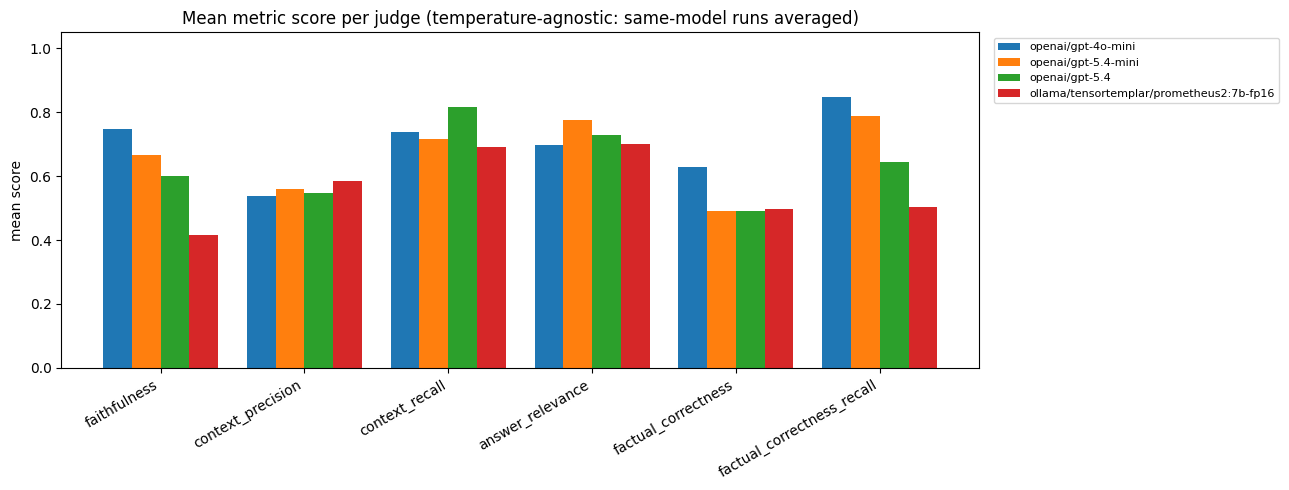

,metric,judge_A,judge_B,n,pearson,spearman,mae
0,faithfulness,openai/gpt-4o-mini,openai/gpt-5.4-mini,16,0.7869,0.6014,0.1688
1,context_precision,openai/gpt-4o-mini,openai/gpt-5.4-mini,19,0.7301,0.7779,0.1325
2,context_recall,openai/gpt-4o-mini,openai/gpt-5.4-mini,19,0.6955,0.6254,0.1404
3,answer_relevance,openai/gpt-4o-mini,openai/gpt-5.4-mini,20,0.8190,0.6402,0.0963
4,factual_correctness,openai/gpt-4o-mini,openai/gpt-5.4-mini,20,0.4372,0.3498,0.2245
5,factual_correctness_recall,openai/gpt-4o-mini,openai/gpt-5.4-mini,19,0.8320,0.7396,0.0979
6,faithfulness,openai/gpt-4o-mini,openai/gpt-5.4,14,0.6115,0.4273,0.2300
7,context_precision,openai/gpt-4o-mini,openai/gpt-5.4,19,0.8392,0.8145,0.1254
8,context_recall,openai/gpt-4o-mini,openai/gpt-5.4,19,0.1143,0.0153,0.2982
9,answer_relevance,openai/gpt-4o-mini,openai/gpt-5.4,20,0.9846,0.8182,0.0497


In [103]:
# Bar chart: mean score per judge model
x      = np.arange(len(metric_cols_present))
bar_w  = min(0.8 / max(len(JUDGE_KEYS), 1), 0.35)
offsets = np.linspace(-(len(JUDGE_KEYS)-1)/2, (len(JUDGE_KEYS)-1)/2, len(JUDGE_KEYS)) * bar_w

fig, ax = plt.subplots(figsize=(13, 5))
for offset, jk, safe in zip(offsets, JUDGE_KEYS, JUDGE_SAFE):
    vals = [judge_wide[f"{c}__{safe}"].mean() if f"{c}__{safe}" in judge_wide.columns else np.nan
            for c in metric_cols_present]
    ax.bar(x + offset, vals, bar_w, label=jk)
ax.set_xticks(x)
ax.set_xticklabels(metric_cols_present, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean score")
ax.set_title("Mean metric score per judge (temperature-agnostic: same-model runs averaged)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Pairwise agreement table (judge model vs judge model)
agree_rows = []
for (jk_l, safe_l), (jk_r, safe_r) in itertools.combinations(zip(JUDGE_KEYS, JUDGE_SAFE), 2):
    for c in metric_cols_present:
        col_l, col_r = f"{c}__{safe_l}", f"{c}__{safe_r}"
        if col_l not in judge_wide.columns or col_r not in judge_wide.columns:
            continue
        a, b = judge_wide[col_l], judge_wide[col_r]
        mask = a.notna() & b.notna()
        a_, b_ = a[mask], b[mask]
        n = int(mask.sum())
        agree_rows.append({
            "metric":    c,
            "judge_A":   jk_l,
            "judge_B":   jk_r,
            "n":         n,
            "pearson":   a_.corr(b_, method="pearson")  if n > 1 else np.nan,
            "spearman":  a_.corr(b_, method="spearman") if n > 1 else np.nan,
            "mae":       (a_ - b_).abs().mean()         if n else np.nan,
        })
agree_df = pd.DataFrame(agree_rows).round(4)
display(agree_df)

## 4. Score-delta heatmaps

Each heatmap shows the **signed score difference** (judge A − judge B) per question (rows) and metric (columns).  
Red = A scored higher · Blue = B scored higher · White = agreement.

Comparing heatmaps across different judge pairs reveals which questions/metrics are **consistently controversial** — i.e., judges diverge on the same cells regardless of which pair you look at.

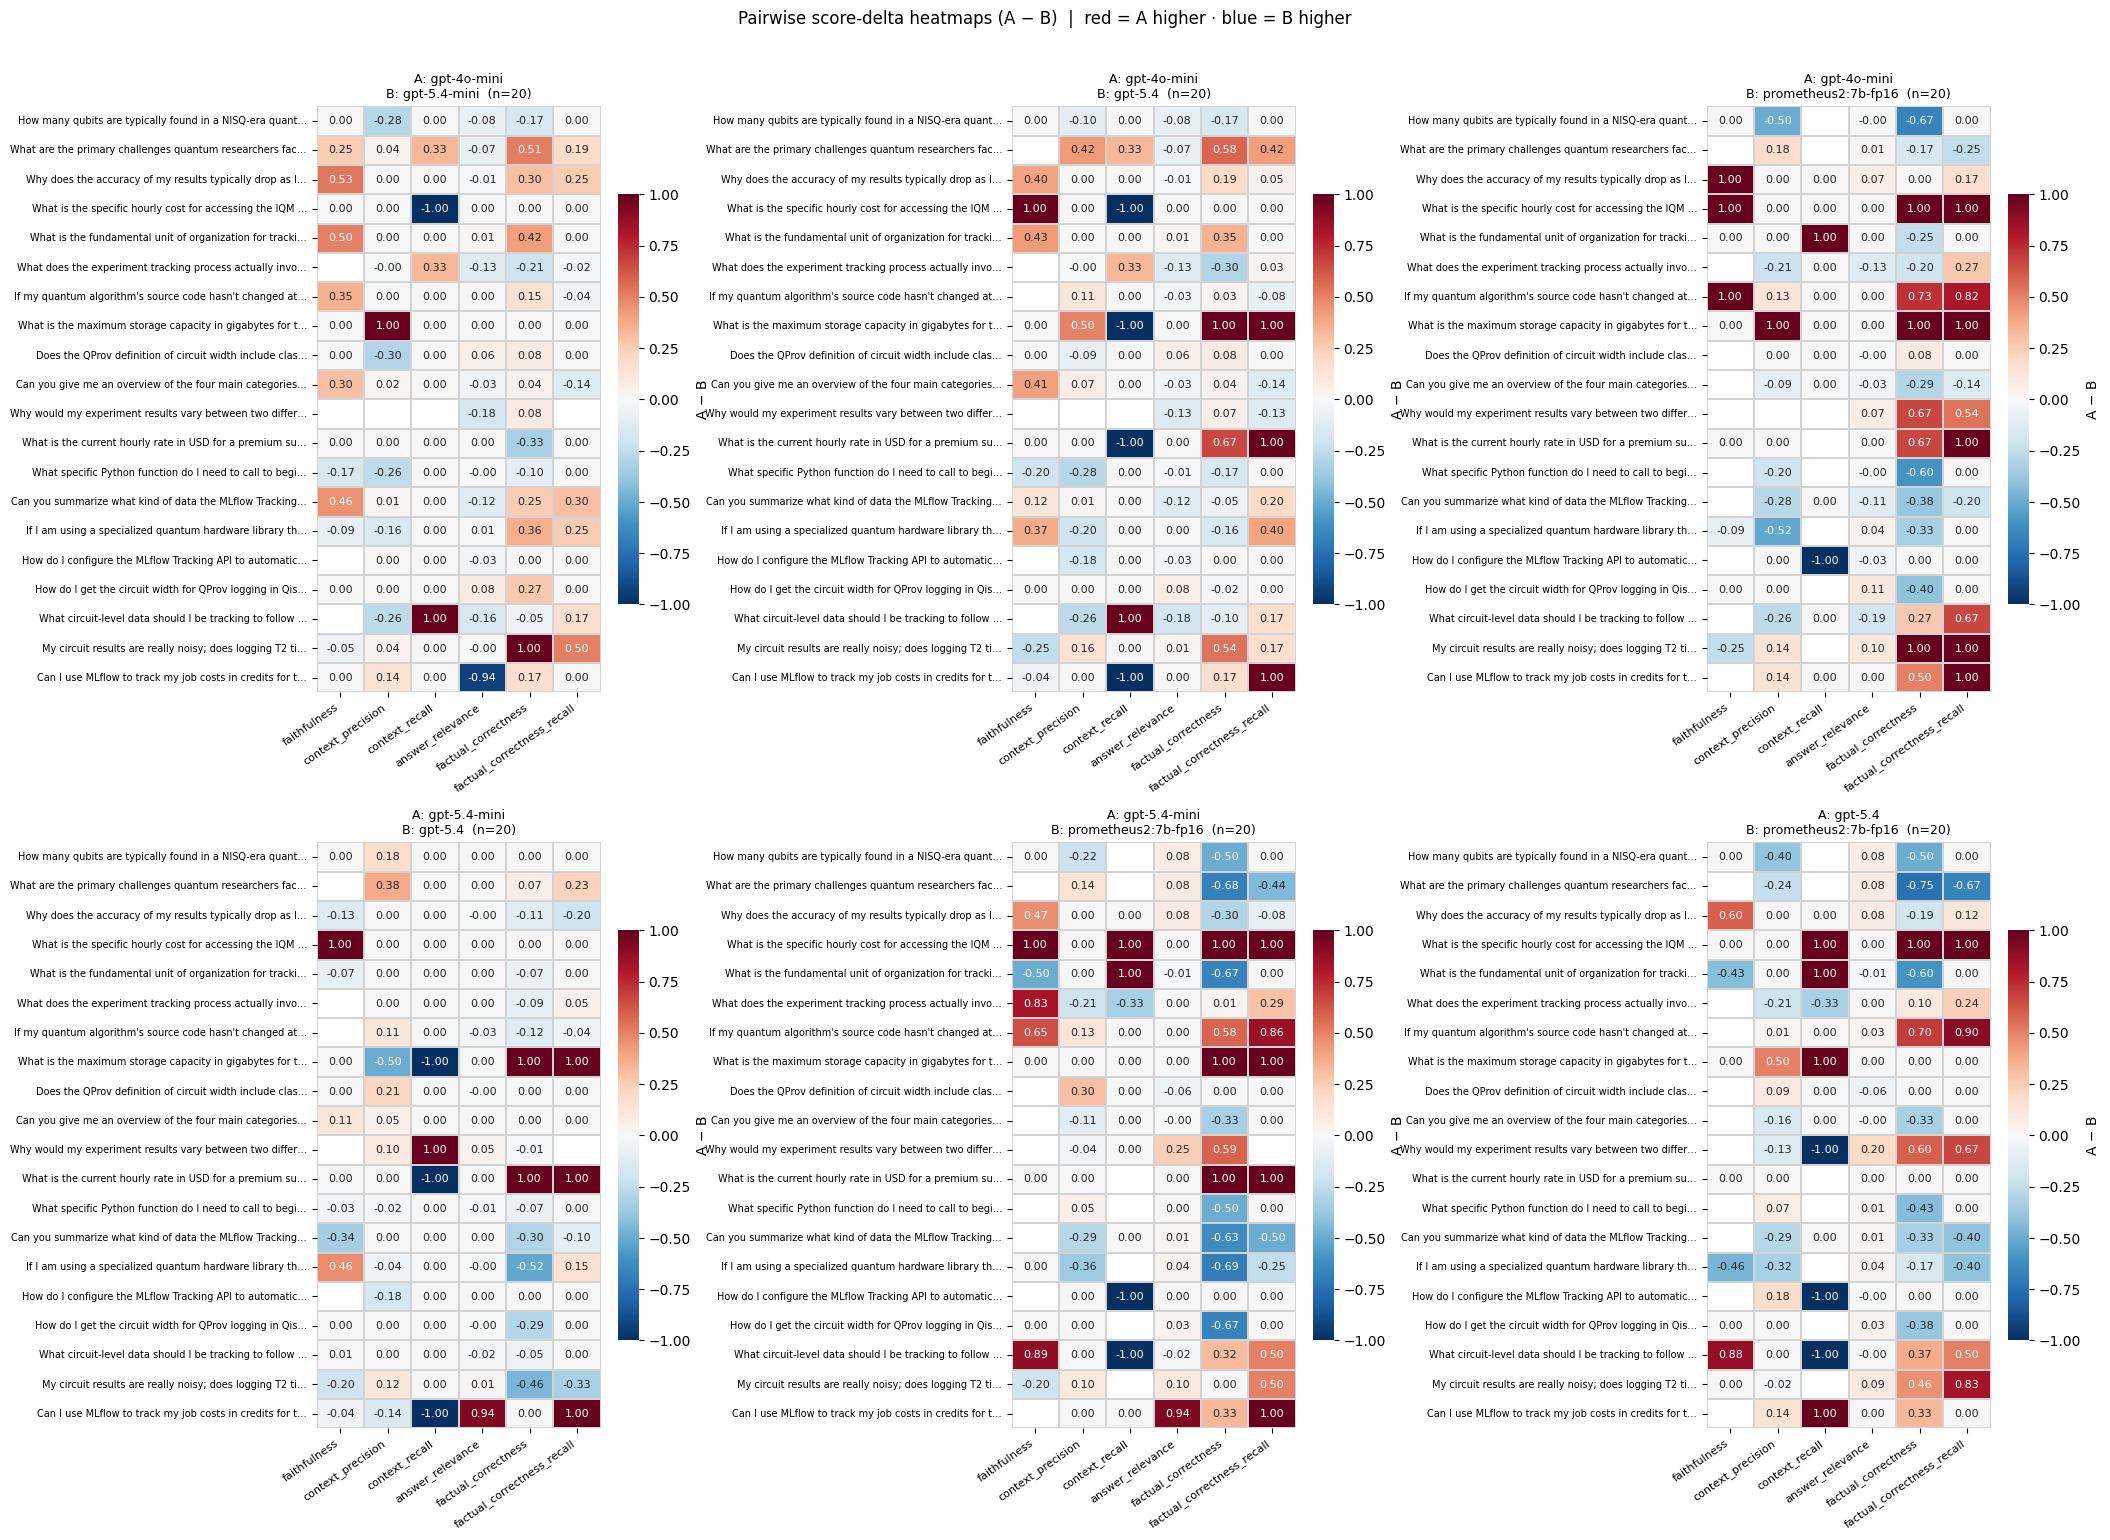

In [104]:
# Build per-pair delta matrices using pairwise inner joins (handles partial dataset overlap)
# Pairs are all distinct run-label combinations — judges AND temperature variants included here.
pair_deltas = {}  # (lbl_l, lbl_r) → (delta_matrix, merged_df)

for lbl_l, lbl_r in itertools.combinations(all_labels, 2):
    sub_l = per_run_dfs[lbl_l][JOIN_KEYS + metric_cols_present].rename(
        columns={c: f"{c}__L" for c in metric_cols_present})
    sub_r = per_run_dfs[lbl_r][JOIN_KEYS + metric_cols_present].rename(
        columns={c: f"{c}__R" for c in metric_cols_present})
    pw = sub_l.merge(sub_r, on=JOIN_KEYS, how="inner")
    if len(pw) == 0:
        continue
    delta_mat = np.full((len(pw), len(metric_cols_present)), np.nan)
    for j, c in enumerate(metric_cols_present):
        if f"{c}__L" in pw.columns and f"{c}__R" in pw.columns:
            delta_mat[:, j] = pw[f"{c}__L"].values - pw[f"{c}__R"].values
    pair_deltas[(lbl_l, lbl_r)] = (delta_mat, pw)

n_pairs = len(pair_deltas)
if n_pairs == 0:
    print("No overlapping question pairs found across any run combination.")
else:
    COLS_PER_ROW = 3
    n_rows = int(np.ceil(n_pairs / COLS_PER_ROW))
    n_q_max = max(len(pw) for _, pw in pair_deltas.values())
    fig, axes = plt.subplots(
        n_rows, min(n_pairs, COLS_PER_ROW),
        figsize=(7 * min(n_pairs, COLS_PER_ROW), max(6, n_q_max * 0.38) * n_rows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax_idx, ((lbl_l, lbl_r), (delta_mat, pw)) in enumerate(pair_deltas.items()):
        ylabels = [shorten(q) for q in pw["user_input"]]
        jk_l = runs_meta[lbl_l]["judge_key"].split("/")[-1]
        jk_r = runs_meta[lbl_r]["judge_key"].split("/")[-1]
        t_l  = runs_meta[lbl_l]["temperature"]
        t_r  = runs_meta[lbl_r]["temperature"]
        tag_l = f"{jk_l}" + (f" t={t_l}" if t_l is not None else "")
        tag_r = f"{jk_r}" + (f" t={t_r}" if t_r is not None else "")
        plot_delta_heatmap(
            axes_flat[ax_idx], delta_mat, ylabels, metric_cols_present,
            f"A: {tag_l}\nB: {tag_r}  (n={len(pw)})",
        )

    for ax in axes_flat[n_pairs:]:
        ax.axis("off")

    plt.suptitle("Pairwise score-delta heatmaps (A − B)  |  red = A higher · blue = B higher",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_613645/2821622509.py:64: RuntimeWarning: Mean of empty slice
  mat[i] = np.nanmean(np.abs(vals) if absolute else vals, axis=0)


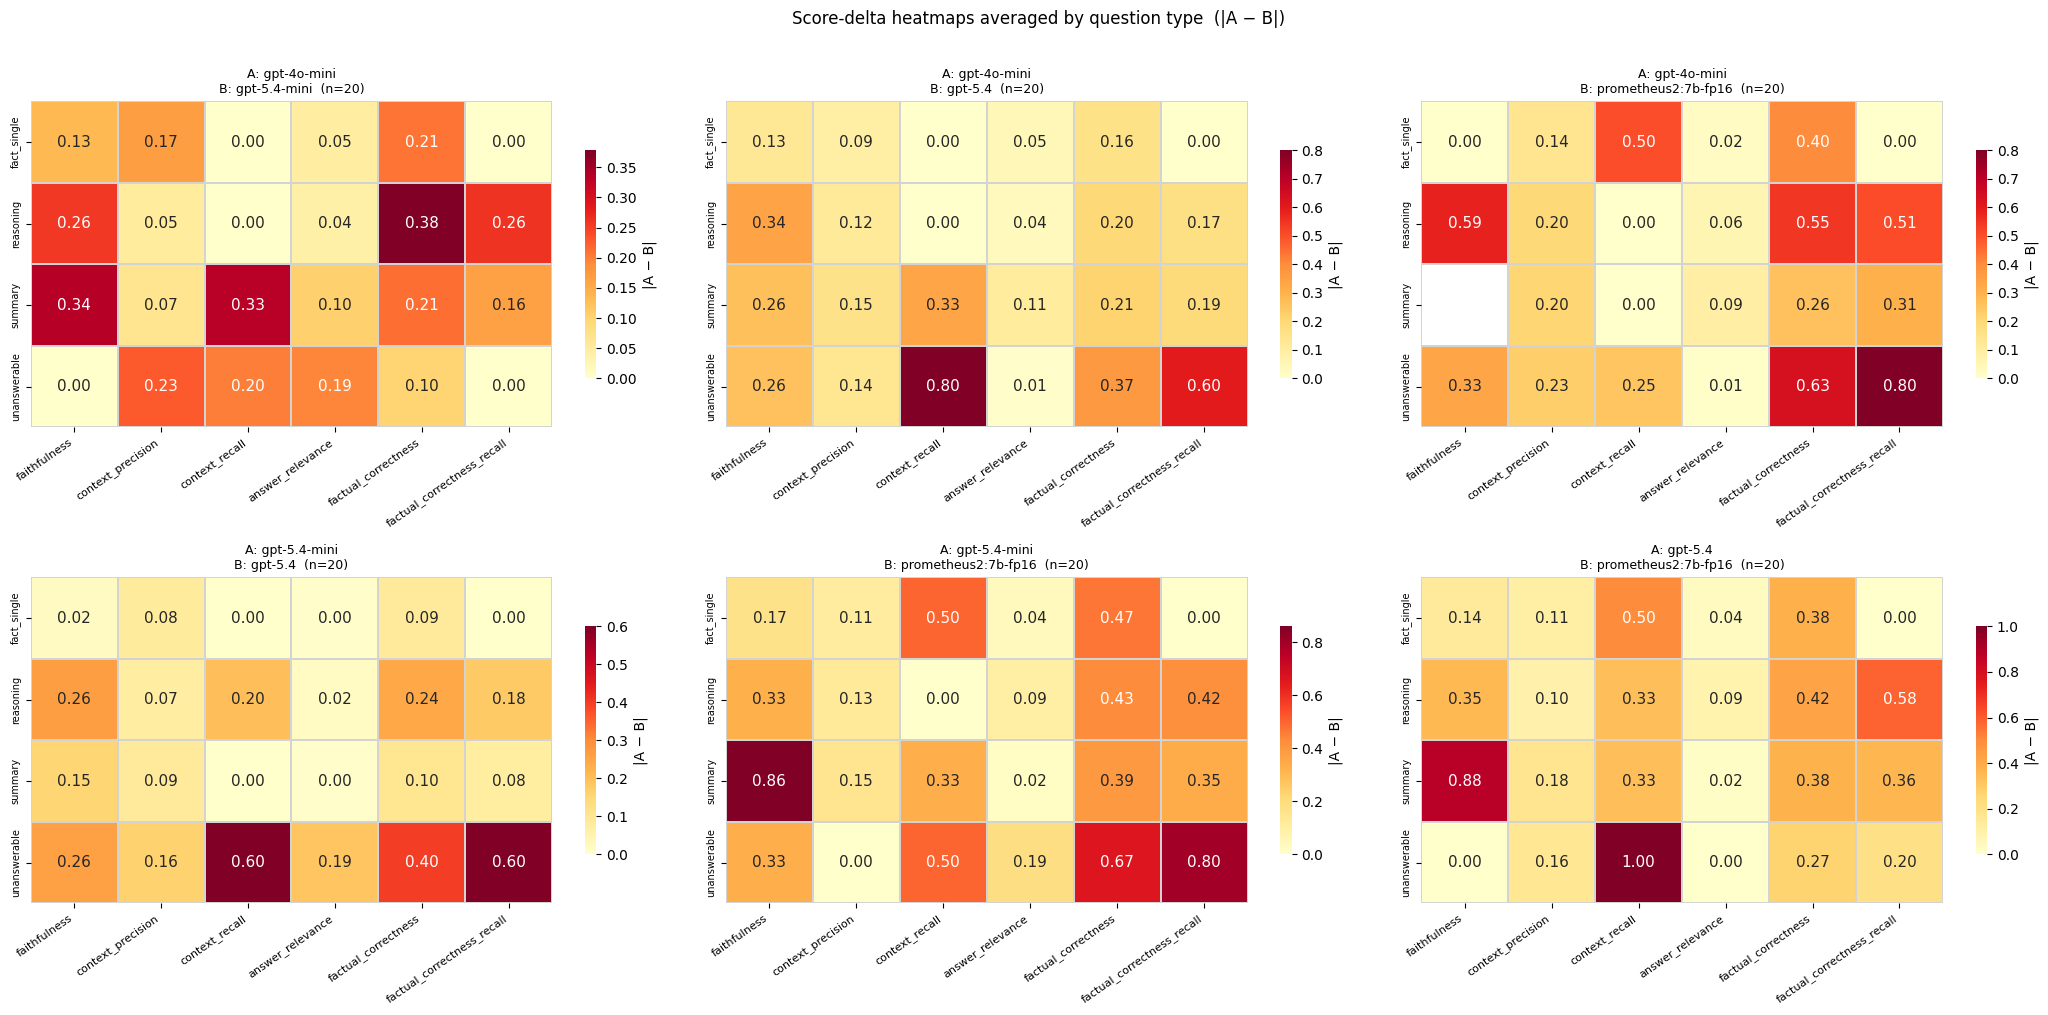

In [105]:
# Section 4b — same delta heatmaps but rows = question_class (averaged across questions in each class)
if pair_deltas:
    absolute = DELTA_MODE == "absolute"
    agg_label = "|A − B|" if absolute else "A − B"

    COLS_PER_ROW = 3
    n_pairs = len(pair_deltas)
    n_rows = int(np.ceil(n_pairs / COLS_PER_ROW))
    fig, axes = plt.subplots(
        n_rows, min(n_pairs, COLS_PER_ROW),
        figsize=(7 * min(n_pairs, COLS_PER_ROW), 5 * n_rows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax_idx, ((lbl_l, lbl_r), (delta_mat, pw)) in enumerate(pair_deltas.items()):
        unique_classes, class_delta = aggregate_by_class(delta_mat, pw, metric_cols_present, absolute=absolute)
        jk_l = runs_meta[lbl_l]["judge_key"].split("/")[-1]
        jk_r = runs_meta[lbl_r]["judge_key"].split("/")[-1]
        t_l  = runs_meta[lbl_l]["temperature"]
        t_r  = runs_meta[lbl_r]["temperature"]
        tag_l = f"{jk_l}" + (f" t={t_l}" if t_l is not None else "")
        tag_r = f"{jk_r}" + (f" t={t_r}" if t_r is not None else "")
        plot_delta_heatmap(
            axes_flat[ax_idx], class_delta, unique_classes, metric_cols_present,
            f"A: {tag_l}\nB: {tag_r}  (n={len(pw)})",
            absolute=absolute,
        )

    for ax in axes_flat[n_pairs:]:
        ax.axis("off")

    plt.suptitle(f"Score-delta heatmaps averaged by question type  ({agg_label})",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [106]:
# # Section 4c — same delta heatmaps but rows = question_class, specific to Target Model vs Others
# TARGET_MODEL = "gpt-5.4"  # Exact target model name to compare against others

# # Filter pair_deltas for exactly one match of the target model
# target_pairs = {}
# for (lbl_l, lbl_r), (delta_mat, pw) in pair_deltas.items():
#     jk_l_model = runs_meta[lbl_l]["judge_key"].split("/")[-1]
#     jk_r_model = runs_meta[lbl_r]["judge_key"].split("/")[-1]
#     has_l = jk_l_model == TARGET_MODEL
#     has_r = jk_r_model == TARGET_MODEL
#     if has_l ^ has_r:
#         # Orient so the target model is always A (left)
#         if has_r:
#             target_pairs[(lbl_r, lbl_l)] = (-delta_mat, pw)
#         else:
#             target_pairs[(lbl_l, lbl_r)] = (delta_mat, pw)

# if target_pairs:
#     absolute = DELTA_MODE == "absolute"
#     agg_label = "|A − B|" if absolute else "A − B"

#     COLS_PER_ROW = 1
#     n_pairs = len(target_pairs)
#     n_rows = int(np.ceil(n_pairs / COLS_PER_ROW))
#     fig, axes = plt.subplots(
#         n_rows, min(n_pairs, COLS_PER_ROW),
#         figsize=(7 * min(n_pairs, COLS_PER_ROW), 5 * n_rows),
#         squeeze=False,
#     )
#     axes_flat = axes.ravel()

#     for ax_idx, ((lbl_l, lbl_r), (delta_mat, pw)) in enumerate(target_pairs.items()):
#         unique_classes, class_delta = aggregate_by_class(delta_mat, pw, metric_cols_present, absolute=absolute)
#         jk_l = runs_meta[lbl_l]["judge_key"].split("/")[-1]
#         jk_r = runs_meta[lbl_r]["judge_key"].split("/")[-1]
#         t_l  = runs_meta[lbl_l]["temperature"]
#         t_r  = runs_meta[lbl_r]["temperature"]
#         tag_l = f"{jk_l}" + (f" t={t_l}" if t_l is not None else "")
#         tag_r = f"{jk_r}" + (f" t={t_r}" if t_r is not None else "")
#         plot_delta_heatmap(
#             axes_flat[ax_idx], class_delta, unique_classes, metric_cols_present,
#             f"A (Target): {tag_l}\nB: {tag_r}  (n={len(pw)})",
#         )

#     for ax in axes_flat[n_pairs:]:
#         ax.axis("off")

#     plt.suptitle(
#         f"Target Model ({TARGET_MODEL}) vs Others: Score-delta heatmaps averaged by question type ({agg_label})",
#         fontsize=12, y=1.01,
#     )
#     plt.tight_layout()
#     plt.show()
# else:
#     print(f"No pairs found containing target model indicator: '{TARGET_MODEL}'")

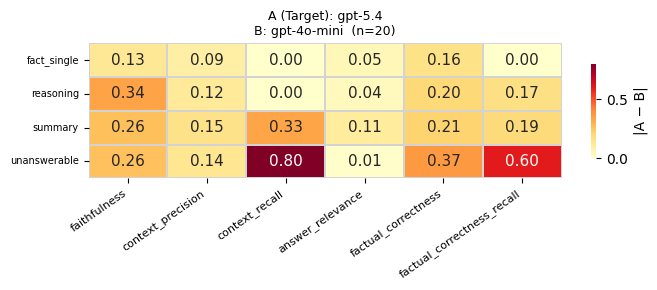

Saved: figures/delta_gpt_5_4_vs_gpt_4o_mini.pdf


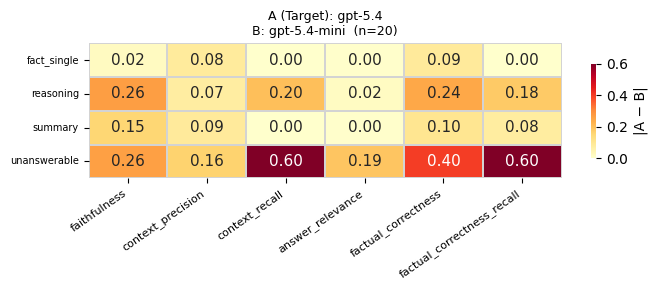

Saved: figures/delta_gpt_5_4_vs_gpt_5_4_mini.pdf


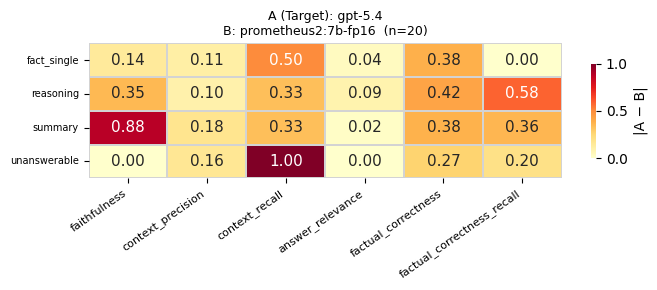

Saved: figures/delta_gpt_5_4_vs_prometheus2:7b_fp16.pdf


In [107]:
# Section 4c (export) — same heatmaps as above, one figure per pair saved to disk
EXPORT_DIR = "figures"
EXPORT_FORMAT = "pdf"  # "pdf" for vector (recommended for thesis) or "png"
EXPORT_DPI = 300       # only used for png

import os
os.makedirs(EXPORT_DIR, exist_ok=True)

absolute = DELTA_MODE == "absolute"

for (lbl_l, lbl_r), (delta_mat, pw) in target_pairs.items():
    unique_classes, class_delta = aggregate_by_class(delta_mat, pw, metric_cols_present, absolute=absolute)

    jk_l = runs_meta[lbl_l]["judge_key"].split("/")[-1]
    jk_r = runs_meta[lbl_r]["judge_key"].split("/")[-1]
    t_l  = runs_meta[lbl_l]["temperature"]
    t_r  = runs_meta[lbl_r]["temperature"]
    tag_l = f"{jk_l}" + (f"_t{t_l}" if t_l is not None else "")
    tag_r = f"{jk_r}" + (f"_t{t_r}" if t_r is not None else "")

    fig, ax = plt.subplots(figsize=(7, max(3, len(unique_classes) * 0.7)))
    plot_delta_heatmap(
        ax, class_delta, unique_classes, metric_cols_present,
        f"A (Target): {jk_l}\nB: {jk_r}  (n={len(pw)})",
        absolute=absolute,
    )
    plt.tight_layout()

    fname = f"{EXPORT_DIR}/delta_{safe_key(tag_l)}_vs_{safe_key(tag_r)}.{EXPORT_FORMAT}"
    fig.savefig(fname, dpi=EXPORT_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## 5. Hard-to-judge analysis

The **inter-judge std** for each (question × metric) cell measures how inconsistently judges score that cell across all judge models.  
High std = judges diverge = this question/metric combination is hard to judge reliably.

The right panel shows a per-question *hardness* score (mean std across all metrics), sorted descending — the rows that appear "hot" across many judge-pair heatmaps will rank highest here.

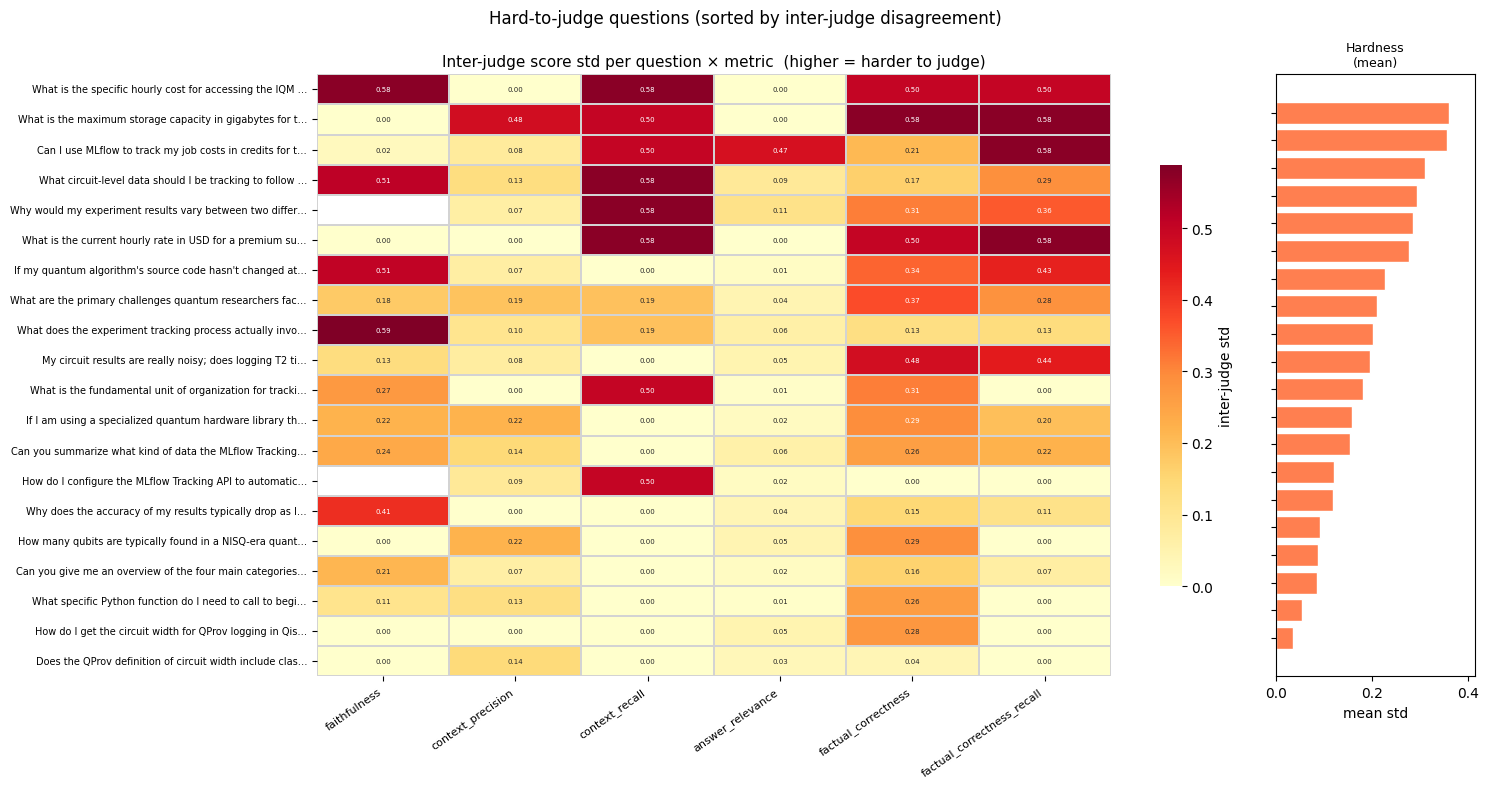


Top 10 hardest-to-judge questions:


,question,question_class,subdomain,mean_std
0,What is the specific hourly cost for accessing...,unanswerable,nisq_constraints_and_qsd_constraints,0.3591
1,What is the maximum storage capacity in gigaby...,unanswerable,experiment_tracking_fundamentals,0.3556
2,Can I use MLflow to track my job costs in cred...,unanswerable,qiskit-specific_experiment_tracking_using_mlfl...,0.3102
3,What circuit-level data should I be tracking t...,summary,qiskit-specific_experiment_tracking_using_mlfl...,0.2938
4,Why would my experiment results vary between t...,reasoning,qprov_provenance_taxonomy,0.2857
5,What is the current hourly rate in USD for a p...,unanswerable,qprov_provenance_taxonomy,0.2759
6,If my quantum algorithm's source code hasn't c...,reasoning,experiment_tracking_fundamentals,0.2271
7,What are the primary challenges quantum resear...,summary,nisq_constraints_and_qsd_constraints,0.2099
8,What does the experiment tracking process actu...,summary,experiment_tracking_fundamentals,0.2020
9,My circuit results are really noisy; does logg...,reasoning,qiskit-specific_experiment_tracking_using_mlfl...,0.1952


In [108]:
# Use the judge_wide table (averaged per judge model) for inter-judge std.
# judge_wide already covers the shared-question subset and averages same-model runs.
n_q = len(judge_wide)
std_matrix = np.full((n_q, len(metric_cols_present)), np.nan)

for j, c in enumerate(metric_cols_present):
    cols = [f"{c}__{s}" for s in JUDGE_SAFE if f"{c}__{s}" in judge_wide.columns]
    if len(cols) > 1:
        std_matrix[:, j] = judge_wide[cols].std(axis=1).values

hardness   = np.nanmean(std_matrix, axis=1)
sort_idx   = np.argsort(hardness)[::-1]
std_sorted = std_matrix[sort_idx]
hard_sorted = hardness[sort_idx]
ylabels_all    = [shorten(q) for q in judge_wide["user_input"]]
ylabels_sorted = [ylabels_all[i] for i in sort_idx]

annot_kws = {"size": max(5, 9 - n_q // 5)}
fig, axes = plt.subplots(
    1, 2, figsize=(15, max(6, n_q * 0.4)),
    gridspec_kw={"width_ratios": [5, 1]},
)
sns.heatmap(
    std_sorted, ax=axes[0],
    xticklabels=metric_cols_present, yticklabels=ylabels_sorted,
    cmap="YlOrRd", vmin=0,
    linewidths=0.3, linecolor="lightgrey",
    annot=True, fmt=".2f", annot_kws=annot_kws,
    cbar_kws={"label": "inter-judge std", "shrink": 0.7},
)
axes[0].set_title("Inter-judge score std per question × metric  (higher = harder to judge)", fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=7)

axes[1].barh(range(n_q), hard_sorted, color="coral", edgecolor="white")
axes[1].set_yticks(range(n_q))
axes[1].set_yticklabels([])
axes[1].invert_yaxis()
axes[1].set_xlabel("mean std")
axes[1].set_title("Hardness\n(mean)", fontsize=9)
axes[1].set_xlim(0, max(float(np.nanmax(hard_sorted)) * 1.15, 0.05))

plt.suptitle("Hard-to-judge questions (sorted by inter-judge disagreement)", fontsize=12)
plt.tight_layout()
plt.show()

TOP_N = 10
hard_df = pd.DataFrame({
    "question":       judge_wide["user_input"].iloc[sort_idx].values,
    "question_class": judge_wide["question_class"].iloc[sort_idx].values,
    "subdomain":      judge_wide["subdomain"].iloc[sort_idx].values,
    "mean_std":       hard_sorted.round(4),
})
print(f"\nTop {TOP_N} hardest-to-judge questions:")
display(hard_df.head(TOP_N))


Inter-judge std by question_class:


,question_class,n,mean_interjudge_std,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
3,unanswerable,5,0.2900,0.1504,0.1299,0.5309,0.0969,0.3574,0.4464
1,reasoning,5,0.1940,0.3177,0.0865,0.1155,0.0474,0.3143,0.3076
2,summary,5,0.1893,0.3455,0.1267,0.1925,0.0549,0.2163,0.2001
0,fact_single,5,0.0895,0.0754,0.0974,0.1000,0.0280,0.2365,0.0000



Inter-judge std by subdomain:


,subdomain,n,mean_interjudge_std,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
0,experiment_tracking_fundamentals,4,0.2416,0.3415,0.1631,0.2981,0.0215,0.3395,0.2859
3,qiskit-specific_experiment_tracking_using_mlfl...,4,0.2133,0.1667,0.0721,0.2693,0.1632,0.2814,0.3268
2,nisq_constraints_and_qsd_constraints,4,0.1951,0.2916,0.1023,0.1925,0.0323,0.3274,0.2245
4,qprov_provenance_taxonomy,4,0.1663,0.0710,0.0691,0.2887,0.0414,0.2530,0.2507
1,mlflow_tracking_api,4,0.1296,0.1881,0.1440,0.1250,0.0256,0.2044,0.1048


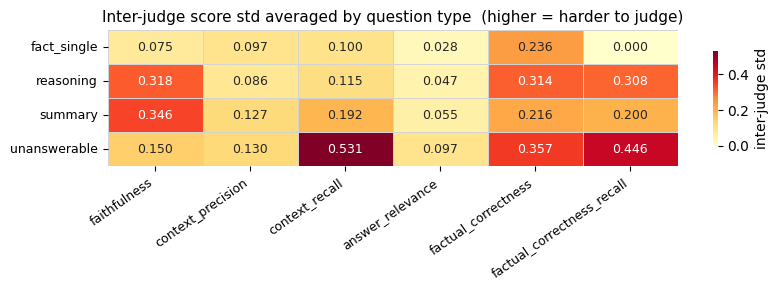

In [109]:
# Group-level inter-judge disagreement tables
for group_col in ["question_class", "subdomain"]:
    rows = []
    for gval, gidx in judge_wide.groupby(group_col).groups.items():
        sub_std = std_matrix[list(gidx)]
        row = {
            group_col: gval,
            "n": len(gidx),
            "mean_interjudge_std": round(float(np.nanmean(sub_std)), 4),
        }
        for j, c in enumerate(metric_cols_present):
            row[c] = round(float(np.nanmean(sub_std[:, j])), 4)
        rows.append(row)
    grp = pd.DataFrame(rows).sort_values("mean_interjudge_std", ascending=False)
    print(f"\nInter-judge std by {group_col}:")
    display(grp)

# Inter-judge std heatmap averaged by question_class
unique_classes = sorted(judge_wide["question_class"].dropna().unique())
class_std = np.full((len(unique_classes), len(metric_cols_present)), np.nan)
for i, qc in enumerate(unique_classes):
    mask = (judge_wide["question_class"] == qc).values
    if mask.sum() > 0:
        class_std[i] = np.nanmean(std_matrix[mask], axis=0)

fig, ax = plt.subplots(figsize=(max(8, len(metric_cols_present) * 1.4), max(3, len(unique_classes) * 0.7)))
sns.heatmap(
    class_std, ax=ax,
    xticklabels=metric_cols_present, yticklabels=unique_classes,
    cmap="YlOrRd", vmin=0,
    linewidths=0.5, linecolor="lightgrey",
    annot=True, fmt=".3f", annot_kws={"size": 9},
    cbar_kws={"label": "inter-judge std", "shrink": 0.7},
)
ax.set_title("Inter-judge score std averaged by question type  (higher = harder to judge)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.show()

## 6. Temperature effect

Compares runs that use the **same judge model** at different temperature settings.  
A large delta between temperatures on the same question/metric suggests the judge's scoring is temperature-sensitive there.

In [110]:
# Identify judge models that appear with more than one run (any temperature combination)
temp_groups = defaultdict(list)  # judge_key → [(label, temperature)]
for lbl, meta in runs_meta.items():
    temp_groups[meta["judge_key"]].append((lbl, meta["temperature"]))

# Keep only judges with >1 run (temperature comparison is meaningful)
temp_judges = {jk: runs for jk, runs in temp_groups.items() if len(runs) > 1}

if not temp_judges:
    print("No judge model has more than one run — nothing to compare for temperature effect.")
    print("Run inventory:")
    for lbl, meta in runs_meta.items():
        print(f"  {lbl}: {meta['judge_key']} temp={meta['temperature']}")
else:
    for jk, label_temps in temp_judges.items():
        label_temps_sorted = sorted(label_temps, key=lambda x: (x[1] is None, x[1] or 0))
        temp_str = {lbl: (f"t={t}" if t is not None else "t=default") for lbl, t in label_temps_sorted}

        # Align all runs of this judge on shared questions
        sub_wide = None
        for lbl, _ in label_temps_sorted:
            sub = per_run_dfs[lbl][JOIN_KEYS + metric_cols_present].rename(
                columns={c: f"{c}__{lbl}" for c in metric_cols_present})
            sub_wide = sub if sub_wide is None else sub_wide.merge(sub, on=JOIN_KEYS, how="inner")

        if sub_wide is None or len(sub_wide) == 0:
            print(f"\n{jk}: No shared questions across its runs — skipping.")
            continue

        print(f"\n=== {jk} ({len(sub_wide)} shared questions across {len(label_temps_sorted)} runs) ===")

        # Mean metrics per temperature run
        temp_mean_rows = []
        for lbl, _ in label_temps_sorted:
            row = {"run": lbl, "temperature": temp_str[lbl]}
            for c in metric_cols_present:
                col = f"{c}__{lbl}"
                row[c] = sub_wide[col].mean() if col in sub_wide.columns else np.nan
            temp_mean_rows.append(row)
        display(pd.DataFrame(temp_mean_rows).set_index("run").round(4))

        # Bar chart
        x_ = np.arange(len(metric_cols_present))
        bw = min(0.8 / max(len(label_temps_sorted), 1), 0.35)
        offs = np.linspace(-(len(label_temps_sorted)-1)/2, (len(label_temps_sorted)-1)/2,
                           len(label_temps_sorted)) * bw
        fig, ax = plt.subplots(figsize=(11, 4))
        for off, (lbl, _) in zip(offs, label_temps_sorted):
            vals = [sub_wide[f"{c}__{lbl}"].mean() if f"{c}__{lbl}" in sub_wide.columns else np.nan
                    for c in metric_cols_present]
            ax.bar(x_ + off, vals, bw, label=f"{lbl} ({temp_str[lbl]})")
        ax.set_xticks(x_)
        ax.set_xticklabels(metric_cols_present, rotation=30, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("mean score")
        ax.set_title(f"{jk} — mean scores by temperature run")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        # Distribution box plots per metric
        long_rows = []
        for lbl, _ in label_temps_sorted:
            for c in metric_cols_present:
                col = f"{c}__{lbl}"
                if col in sub_wide.columns:
                    for v in sub_wide[col].dropna():
                        long_rows.append({"metric": c, "run": f"{lbl}\n({temp_str[lbl]})", "score": v})
        if long_rows:
            long_df = pd.DataFrame(long_rows)
            run_order = [f"{lbl}\n({temp_str[lbl]})" for lbl, _ in label_temps_sorted]
            fig2, axes2 = plt.subplots(1, len(metric_cols_present),
                                       figsize=(3.2 * len(metric_cols_present), 4))
            for ax2, c in zip(np.array(axes2).ravel(), metric_cols_present):
                sub_long = long_df[long_df["metric"] == c]
                if sub_long.empty:
                    ax2.axis("off"); continue
                sns.boxplot(data=sub_long, x="run", y="score", order=run_order,
                            ax=ax2, palette="Set2", width=0.5)
                ax2.set_title(c, fontsize=9)
                ax2.set_xlabel("")
                ax2.set_ylim(-0.05, 1.1)
                ax2.tick_params(axis="x", labelsize=6, rotation=20)
            plt.suptitle(f"{jk} — score distributions by temperature", fontsize=11)
            plt.tight_layout()
            plt.show()

No judge model has more than one run — nothing to compare for temperature effect.
Run inventory:
  bald_calf_13: openai/gpt-4o-mini temp=None
  spiffy_sponge_952: openai/gpt-5.4-mini temp=None
  powerful_owl_792: openai/gpt-5.4 temp=None
  glamorous_smelt_610: ollama/tensortemplar/prometheus2:7b-fp16 temp=None


In [111]:
# Temperature delta heatmaps — same judge, each run pair as a separate heatmap
for jk, label_temps in temp_judges.items():
    label_temps_sorted = sorted(label_temps, key=lambda x: (x[1] is None, x[1] or 0))
    temp_str = {lbl: (f"t={t}" if t is not None else "t=default") for lbl, t in label_temps_sorted}
    temp_pairs = list(itertools.combinations(label_temps_sorted, 2))
    if not temp_pairs:
        continue

    # Rebuild sub_wide for this judge
    sub_wide = None
    for lbl, _ in label_temps_sorted:
        sub = per_run_dfs[lbl][JOIN_KEYS + metric_cols_present].rename(
            columns={c: f"{c}__{lbl}" for c in metric_cols_present})
        sub_wide = sub if sub_wide is None else sub_wide.merge(sub, on=JOIN_KEYS, how="inner")
    if sub_wide is None or len(sub_wide) == 0:
        continue

    n_tp = len(temp_pairs)
    fig, axes_ = plt.subplots(
        1, n_tp,
        figsize=(7 * n_tp, max(6, len(sub_wide) * 0.4)),
        squeeze=False,
    )
    for ax_, ((lbl_l, _), (lbl_r, __)) in zip(axes_.ravel(), temp_pairs):
        delta_mat = np.full((len(sub_wide), len(metric_cols_present)), np.nan)
        for j, c in enumerate(metric_cols_present):
            col_l, col_r = f"{c}__{lbl_l}", f"{c}__{lbl_r}"
            if col_l in sub_wide.columns and col_r in sub_wide.columns:
                delta_mat[:, j] = sub_wide[col_l].values - sub_wide[col_r].values
        ylabels_ = [shorten(q) for q in sub_wide["user_input"]]
        plot_delta_heatmap(
            ax_, delta_mat, ylabels_, metric_cols_present,
            f"A: {lbl_l} ({temp_str[lbl_l]})\nB: {lbl_r} ({temp_str[lbl_r]})\n(n={len(sub_wide)})",
        )
    plt.suptitle(f"{jk} — temperature delta heatmaps (A − B)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [112]:
# Section 6b — temperature delta heatmaps averaged by question_class
for jk, label_temps in temp_judges.items():
    label_temps_sorted = sorted(label_temps, key=lambda x: (x[1] is None, x[1] or 0))
    temp_str = {lbl: (f"t={t}" if t is not None else "t=default") for lbl, t in label_temps_sorted}
    temp_pairs = list(itertools.combinations(label_temps_sorted, 2))
    if not temp_pairs:
        continue

    sub_wide = None
    for lbl, _ in label_temps_sorted:
        sub = per_run_dfs[lbl][JOIN_KEYS + metric_cols_present].rename(
            columns={c: f"{c}__{lbl}" for c in metric_cols_present})
        sub_wide = sub if sub_wide is None else sub_wide.merge(sub, on=JOIN_KEYS, how="inner")
    if sub_wide is None or len(sub_wide) == 0:
        continue

    absolute = DELTA_MODE == "absolute"
    agg_label = "|A − B|" if absolute else "A − B"

    n_tp = len(temp_pairs)
    fig, axes_ = plt.subplots(
        1, n_tp,
        figsize=(7 * n_tp, max(3, len(sorted(sub_wide["question_class"].dropna().unique())) * 0.7)),
        squeeze=False,
    )
    for ax_, ((lbl_l, _), (lbl_r, __)) in zip(axes_.ravel(), temp_pairs):
        delta_mat = np.full((len(sub_wide), len(metric_cols_present)), np.nan)
        for j, c in enumerate(metric_cols_present):
            col_l, col_r = f"{c}__{lbl_l}", f"{c}__{lbl_r}"
            if col_l in sub_wide.columns and col_r in sub_wide.columns:
                delta_mat[:, j] = sub_wide[col_l].values - sub_wide[col_r].values

        unique_classes, class_delta = aggregate_by_class(delta_mat, sub_wide, metric_cols_present, absolute=absolute)
        plot_delta_heatmap(
            ax_, class_delta, unique_classes, metric_cols_present,
            f"A: {lbl_l} ({temp_str[lbl_l]})\nB: {lbl_r} ({temp_str[lbl_r]})\n(n={len(sub_wide)})",
            absolute=absolute,
        )
    plt.suptitle(f"{jk} — temperature delta by question type  ({agg_label})", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [113]:
# Uncomment to export tables.
# overall_df.to_csv("judge_multi_overall.csv")
# agree_df.to_csv("judge_multi_pairwise_agreement.csv", index=False)
# hard_df.to_csv("judge_multi_hard_questions.csv", index=False)
print("Done.")

Done.
